# OpenNILM - Data Preparation & Training (PyTorch)

This notebook covers:
1. **Data Preparation**: Loading and preprocessing NILM datasets (REFIT/PLEGMA)
2. **Model Configuration**: Setting up CNN, GRU, or TCN models
3. **Training**: Training the model with early stopping and checkpointing
4. **Visualization**: Training curves and model analysis

---

## Google Colab Setup

**If running on Colab:**
1. Upload your `OpenNILM` folder to Google Drive (e.g., `My Drive/OpenNILM/`)
2. Run the Colab setup cells below first
3. Edit `DRIVE_PROJECT_PATH` to match your folder location

---

In [33]:
# ============================================================================
# COLAB SETUP - Run this cell first!
# ============================================================================
import sys

# Detect if running on Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive')


    # =========================================================================
    # CONFIGURE YOUR GOOGLE DRIVE PATH HERE
    # =========================================================================
    DRIVE_PROJECT_PATH = '/content/drive/MyDrive/Colab Notebooks/ENERGIZE - EDGE - FRAMEWORK'  # <-- EDIT THIS PATH
    # =========================================================================

    import os
    from pathlib import Path

    project_root = Path(DRIVE_PROJECT_PATH)

    if not project_root.exists():
        print(f"ERROR: Project folder not found at: {project_root}")
        print(f"Please upload OpenNILM to Google Drive or edit DRIVE_PROJECT_PATH above")
        print(f"\nYour Drive contents:")
        !ls "/content/drive/MyDrive/" | head -15
    else:
        os.chdir(project_root)
        sys.path.insert(0, str(project_root))
        print(f"Project root: {project_root}")
        print(f"Working directory: {os.getcwd()}")
else:
    import os
    from pathlib import Path
    project_root = Path(os.getcwd()).parent
    sys.path.insert(0, str(project_root))
    print(f"Running locally. Project root: {project_root}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/Colab Notebooks/ENERGIZE - EDGE - FRAMEWORK
Working directory: /content/drive/MyDrive/Colab Notebooks/ENERGIZE - EDGE - FRAMEWORK


## 1. Setup and Imports

In [34]:
# ============================================================================
# IMPORTS (os, sys, Path, project_root already defined in Colab setup cell)
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# PyTorch NILM modules
from src_pytorch import (
    CNN_NILM, GRU_NILM, TCN_NILM, get_model,
    SimpleNILMDataLoader,
    Trainer, EarlyStopping, ModelCheckpoint, TrainingHistory,
    set_seeds, get_device, count_parameters, print_model_summary,
    # Config
    MODEL_CONFIGS, TRAINING, get_appliance_params, get_model_config
)

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


In [3]:
# Set seeds for reproducibility
set_seeds(42)

# Get device
device = get_device()

Seeds set to 42
Using GPU: NVIDIA A100-SXM4-80GB
GPU Memory: 85.09 GB


## 2. Configuration

Configure the experiment parameters below:

In [35]:
# ============================================================================
# USER CONFIGURATION - Modify these values only
# ============================================================================
DATASET_NAME = 'plegma'      # 'refit' or 'plegma'
APPLIANCE_NAME = 'ac_1'    # REFIT: dishwasher, washing_machine, kettle, microwave, refrigerator
                             # PLEGMA: ac_1, boiler, washing_machine, fridge
MODEL_NAME = 'tcn'           # 'cnn', 'gru', or 'tcn'

# ============================================================================
# AUTO-LOADED FROM CONFIG (src_pytorch/config.py) - Don't modify below
# ============================================================================
# Get model configuration
model_config = get_model_config(MODEL_NAME)
INPUT_WINDOW_LENGTH = model_config['input_window_length']
BATCH_SIZE = model_config['batch_size']

# Get appliance parameters
appliance_params = get_appliance_params(DATASET_NAME, APPLIANCE_NAME)
THRESHOLD = appliance_params['threshold']
CUTOFF = appliance_params['cutoff']
AGG_MEAN = appliance_params['mean']
AGG_STD = appliance_params['std']

# Get training parameters
#washing_machine & AC
# EPOCHS = 100
# LEARNING_RATE = 0.00002
# EARLY_STOPPING_PATIENCE = 40

EPOCHS = 100
LEARNING_RATE = 0.001
EARLY_STOPPING_PATIENCE = 30



# Paths
DATA_DIR = Path('/content/drive/MyDrive/Colab Notebooks/ENERGIZE') / 'data' / 'processed' / DATASET_NAME / APPLIANCE_NAME
OUTPUT_DIR = project_root / 'outputs' / f'{MODEL_NAME}_{APPLIANCE_NAME}'

# Create output directories
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / 'checkpoint').mkdir(exist_ok=True)
(OUTPUT_DIR / 'tensorboard').mkdir(exist_ok=True)
(OUTPUT_DIR / 'figures').mkdir(exist_ok=True)

# Print configuration summary
print("=" * 60)
print("CONFIGURATION")
print("=" * 60)
print(f"Dataset:           {DATASET_NAME}")
print(f"Appliance:         {APPLIANCE_NAME}")
print(f"Model:             {MODEL_NAME}")
print(f"Window length:     {INPUT_WINDOW_LENGTH}")
print(f"Batch size:        {BATCH_SIZE}")
print(f"Epochs:            {EPOCHS}")
print(f"Learning rate:     {LEARNING_RATE}")
print(f"Threshold:         {THRESHOLD} W")
print(f"Cutoff:            {CUTOFF} W")
print(f"Data directory:    {DATA_DIR}")
print(f"Output directory:  {OUTPUT_DIR}")
print("=" * 60)

CONFIGURATION
Dataset:           plegma
Appliance:         ac_1
Model:             tcn
Window length:     600
Batch size:        50
Epochs:            100
Learning rate:     0.001
Threshold:         50 W
Cutoff:            2300 W
Data directory:    /content/drive/MyDrive/Colab Notebooks/ENERGIZE/data/processed/plegma/ac_1
Output directory:  /content/drive/MyDrive/Colab Notebooks/ENERGIZE - EDGE - FRAMEWORK/outputs/tcn_ac_1


## 3. Data Preparation

### 3.1 Load Raw Data (Optional - For Data Exploration)

If you need to process raw data first, run the data processing script:
```bash
cd data
python data.py dataset=refit appliance=dishwasher
```

In [36]:
# Check if processed data exists
if not DATA_DIR.exists():
    print(f"Warning: Data directory does not exist: {DATA_DIR}")
    print("Please run the data processing script first.")
else:
    print(f"Data directory found: {DATA_DIR}")
    print(f"Files: {list(DATA_DIR.glob('*.csv'))}")

Data directory found: /content/drive/MyDrive/Colab Notebooks/ENERGIZE/data/processed/plegma/ac_1
Files: [PosixPath('/content/drive/MyDrive/Colab Notebooks/ENERGIZE/data/processed/plegma/ac_1/training_.csv'), PosixPath('/content/drive/MyDrive/Colab Notebooks/ENERGIZE/data/processed/plegma/ac_1/validation_.csv'), PosixPath('/content/drive/MyDrive/Colab Notebooks/ENERGIZE/data/processed/plegma/ac_1/test_.csv')]


### 3.2 Explore the Processed Data

In [37]:
# Load and explore the training data
train_df = pd.read_csv(DATA_DIR / 'training_.csv')
val_df = pd.read_csv(DATA_DIR / 'validation_.csv')
test_df = pd.read_csv(DATA_DIR / 'test_.csv')

print("Training data shape:", train_df.shape)
print("Validation data shape:", val_df.shape)
print("Test data shape:", test_df.shape)
print("\nColumn names:", train_df.columns.tolist())
print("\nTraining data statistics:")
train_df.describe()

Training data shape: (19492175, 2)
Validation data shape: (1768248, 2)
Test data shape: (3798581, 2)

Column names: ['aggregate', 'ac_1']

Training data statistics:


,aggregate,ac_1
count,1.949218e+07,1.949218e+07
mean,8.830306e-18,1.726510e-02
std,1.000000e+00,1.078953e-01
min,-4.654972e-01,0.000000e+00
25%,-3.643404e-01,0.000000e+00
50%,-2.517079e-01,0.000000e+00
75%,-1.292217e-01,0.000000e+00
max,1.493408e+01,1.000000e+00


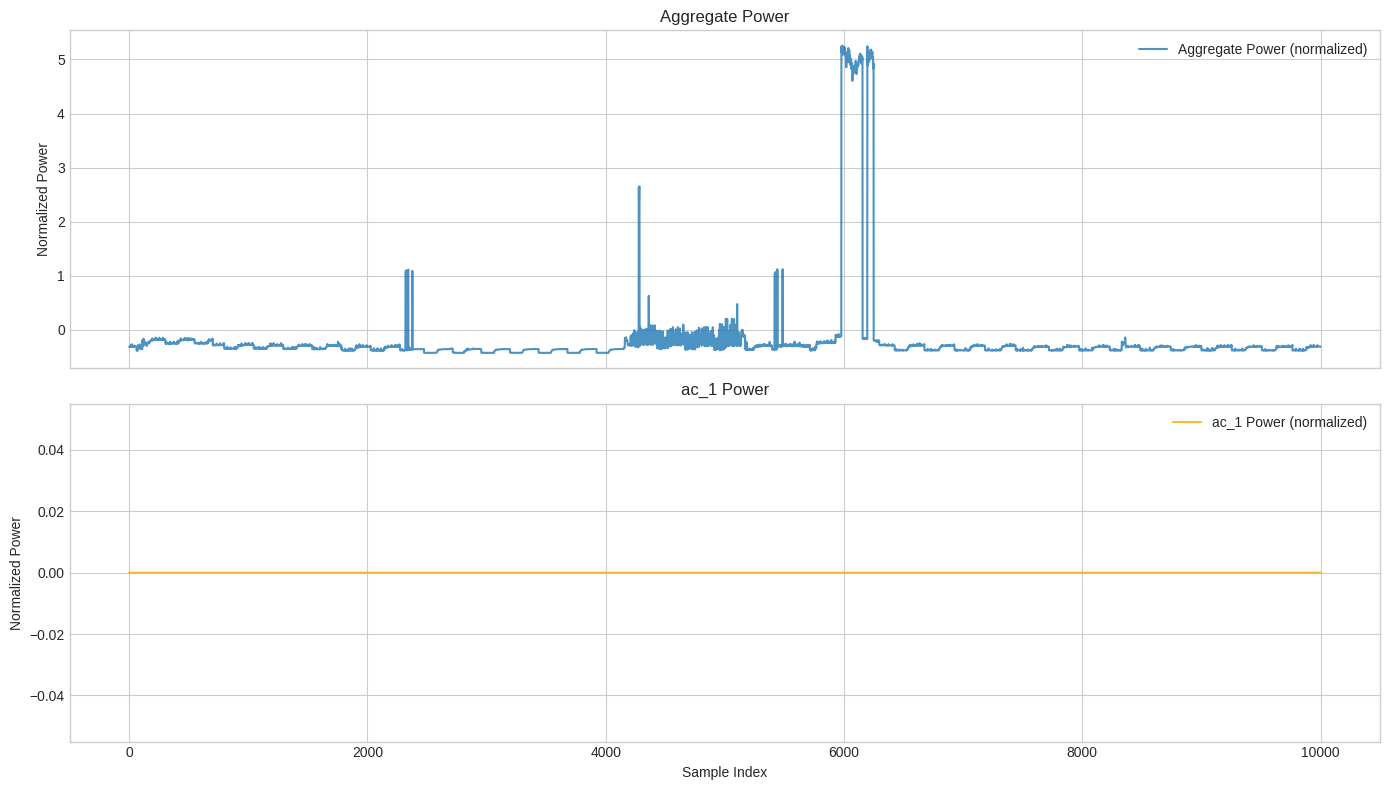

In [38]:
# Visualize a sample of the data
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

sample_size = min(10000, len(train_df))
sample = train_df.iloc[:sample_size]

axes[0].plot(sample.iloc[:, 0], label='Aggregate Power (normalized)', alpha=0.8)
axes[0].set_ylabel('Normalized Power')
axes[0].set_title('Aggregate Power')
axes[0].legend()

axes[1].plot(sample.iloc[:, 1], label=f'{APPLIANCE_NAME} Power (normalized)', alpha=0.8, color='orange')
axes[1].set_ylabel('Normalized Power')
axes[1].set_xlabel('Sample Index')
axes[1].set_title(f'{APPLIANCE_NAME} Power')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / 'data_visualization.png', dpi=150)
plt.show()

### 3.3 Create Data Loaders

In [39]:
# Create data loader
data_loader = SimpleNILMDataLoader(
    data_dir=str(DATA_DIR),
    model_name=MODEL_NAME,
    batch_size=BATCH_SIZE,
    input_window_length=INPUT_WINDOW_LENGTH,
    train=True,
    num_workers=0  # Set to > 0 for parallel data loading
)

# Get data loaders
train_loader = data_loader.train
val_loader = data_loader.val
test_loader = data_loader.test

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# Check a batch
batch_x, batch_y = next(iter(train_loader))
print(f"\nBatch X shape: {batch_x.shape}")
print(f"Batch Y shape: {batch_y.shape}")

Training batches: 649
Validation batches: 59
Test batches: 127

Batch X shape: torch.Size([50, 600, 1])
Batch Y shape: torch.Size([50, 600, 1])


## 4. Model Setup

In [40]:
# Create the model
if MODEL_NAME == 'cnn':
    model = CNN_NILM(input_window_length=INPUT_WINDOW_LENGTH)
elif MODEL_NAME == 'gru':
    model = GRU_NILM(input_window_length=INPUT_WINDOW_LENGTH)
elif MODEL_NAME == 'tcn':
    model = TCN_NILM(
        input_window_length=INPUT_WINDOW_LENGTH,
        depth=model_config.get('depth', 9),
        nb_filters=model_config.get('nb_filters'),
        dropout=model_config.get('dropout', 0.1),
        stacks=model_config.get('stacks', 1)
    )

# Move model to device
model = model.to(device)

# Print model summary
print(f"\nModel: {MODEL_NAME.upper()}")
print(f"Trainable parameters: {count_parameters(model):,}")
print("\nModel architecture:")
print(model)


Model: TCN
Trainable parameters: 3,220,481

Model architecture:
TCN_NILM(
  (initial_conv): Conv1d(1, 512, kernel_size=(1,), stride=(1,))
  (gated_blocks): ModuleList(
    (0): GatedBlock(
      (signal_conv): CausalConv1d(
        (conv): Conv1d(512, 512, kernel_size=(2,), stride=(1,), padding=(1,))
      )
      (gate_conv): CausalConv1d(
        (conv): Conv1d(512, 512, kernel_size=(2,), stride=(1,), padding=(1,))
      )
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (1): GatedBlock(
      (signal_conv): CausalConv1d(
        (conv): Conv1d(512, 256, kernel_size=(2,), stride=(1,), padding=(2,), dilation=(2,))
      )
      (gate_conv): CausalConv1d(
        (conv): Conv1d(512, 256, kernel_size=(2,), stride=(1,), padding=(2,), dilation=(2,))
      )
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (2): GatedBlock(
      (signal_conv): CausalConv1d(
        (conv): Conv1d(256, 256, kernel_size=(2,), stride=(1,), padding=(4,), dilation=(4,))
      )
      (gate_conv

In [41]:
# Test forward pass
with torch.no_grad():
    test_input = batch_x[:2].to(device)
    test_output = model(test_input)
    print(f"Test input shape: {test_input.shape}")
    print(f"Test output shape: {test_output.shape}")

Test input shape: torch.Size([2, 600, 1])
Test output shape: torch.Size([2, 600, 1])


## 5. Training

In [42]:
# Setup optimizer and loss
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    betas=(0.9, 0.999),
    eps=1e-8
)

loss_fn = nn.MSELoss()

# Create trainer
trainer = Trainer(
    model=model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device
)

# Setup callbacks
trainer.setup_callbacks(
    checkpoint_dir=str(OUTPUT_DIR / 'checkpoint'),
    tensorboard_dir=str(OUTPUT_DIR / 'tensorboard'),
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    early_stopping_min_delta=1e-6
)

print("Trainer configured successfully!")
print(f"Checkpoint will be saved to: {OUTPUT_DIR / 'checkpoint' / 'model.pt'}")
print(f"TensorBoard logs will be saved to: {OUTPUT_DIR / 'tensorboard'}")

Trainer configured successfully!
Checkpoint will be saved to: /content/drive/MyDrive/Colab Notebooks/ENERGIZE - EDGE - FRAMEWORK/outputs/tcn_ac_1/checkpoint/model.pt
TensorBoard logs will be saved to: /content/drive/MyDrive/Colab Notebooks/ENERGIZE - EDGE - FRAMEWORK/outputs/tcn_ac_1/tensorboard


In [43]:
# Train the model
print(f"\nStarting training for {EPOCHS} epochs...")
print("=" * 60)

history = trainer.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    verbose=True
)

print("\nTraining completed!")


Starting training for 100 epochs...


Epoch 1: 100%|██████████| 649/649 [00:17<00:00, 36.86it/s, loss=0.00759]


Epoch 1/100 - loss: 0.0080 - val_loss: 0.0293 - mae: 0.0241 - val_mae: 0.0652
Model saved to /content/drive/MyDrive/Colab Notebooks/ENERGIZE - EDGE - FRAMEWORK/outputs/tcn_ac_1/checkpoint/model.pt and /content/drive/MyDrive/Colab Notebooks/ENERGIZE - EDGE - FRAMEWORK/outputs/tcn_ac_1/checkpoint/model.pth (val_loss: 0.029281)


Epoch 2: 100%|██████████| 649/649 [00:17<00:00, 36.69it/s, loss=0.0115]


Epoch 2/100 - loss: 0.0065 - val_loss: 0.0075 - mae: 0.0215 - val_mae: 0.0258
Model saved to /content/drive/MyDrive/Colab Notebooks/ENERGIZE - EDGE - FRAMEWORK/outputs/tcn_ac_1/checkpoint/model.pt and /content/drive/MyDrive/Colab Notebooks/ENERGIZE - EDGE - FRAMEWORK/outputs/tcn_ac_1/checkpoint/model.pth (val_loss: 0.007487)


...

Epoch 93/100 - loss: 0.0019 - val_loss: 0.0074 - mae: 0.0105 - val_mae: 0.0182
EarlyStopping: 28/30


Epoch 94: 100%|██████████| 649/649 [00:17<00:00, 36.82it/s, loss=0.00392]


Epoch 94/100 - loss: 0.0020 - val_loss: 0.0071 - mae: 0.0100 - val_mae: 0.0172
EarlyStopping: 29/30


Epoch 95: 100%|██████████| 649/649 [00:17<00:00, 36.81it/s, loss=0.000832]


Epoch 95/100 - loss: 0.0020 - val_loss: 0.0115 - mae: 0.0103 - val_mae: 0.0247
EarlyStopping: 30/30
Early stopping triggered!

Early stopping at epoch 95

Best epoch: 65 | Best val_loss: 0.005831
Final model saved to /content/drive/MyDrive/Colab Notebooks/ENERGIZE - EDGE - FRAMEWORK/outputs/tcn_ac_1/checkpoint/model_final.pt and /content/drive/MyDrive/Colab Notebooks/ENERGIZE - EDGE - FRAMEWORK/outputs/tcn_ac_1/checkpoint/model_final.pth

Training completed!


## 6. Training Analysis

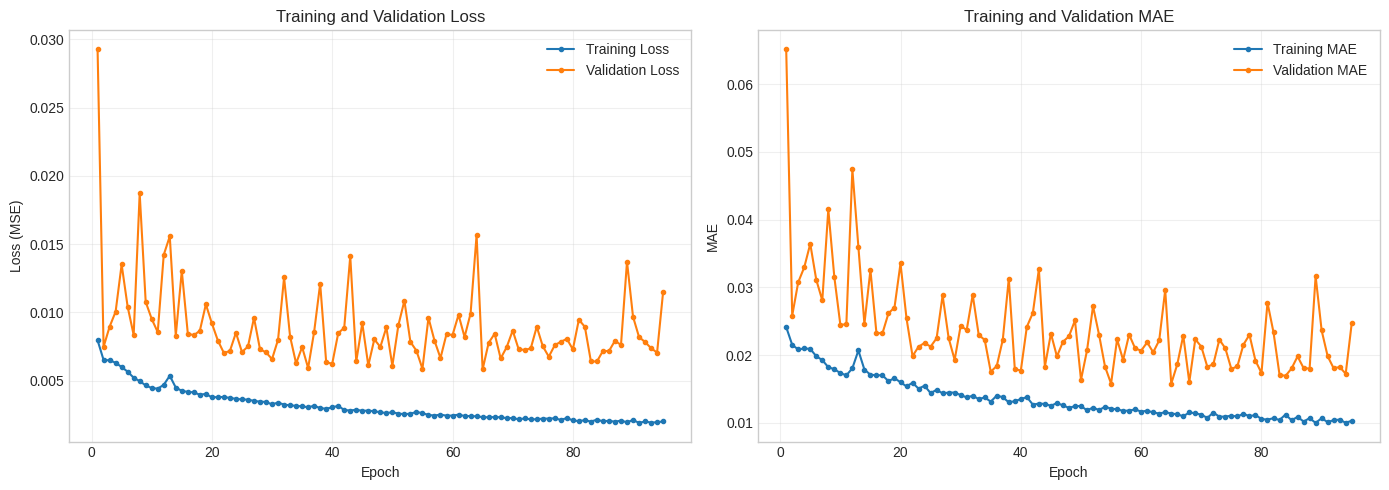


Best epoch: 65
Best validation loss: 0.005831
Best validation MAE: 0.015765


In [44]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history.epochs, history.train_loss, label='Training Loss', marker='o', markersize=3)
axes[0].plot(history.epochs, history.val_loss, label='Validation Loss', marker='o', markersize=3)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE plot
if history.train_mae:
    axes[1].plot(history.epochs, history.train_mae, label='Training MAE', marker='o', markersize=3)
    axes[1].plot(history.epochs, history.val_mae, label='Validation MAE', marker='o', markersize=3)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].set_title('Training and Validation MAE')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / 'training_curves.png', dpi=150)
plt.show()

# Print best results
best_epoch = np.argmin(history.val_loss)
print(f"\nBest epoch: {best_epoch + 1}")
print(f"Best validation loss: {history.val_loss[best_epoch]:.6f}")
print(f"Best validation MAE: {history.val_mae[best_epoch]:.6f}" if history.val_mae else "")

In [45]:
# Save training history
history_df = pd.DataFrame({
    'epoch': history.epochs,
    'train_loss': history.train_loss,
    'val_loss': history.val_loss,
    'train_mae': history.train_mae,
    'val_mae': history.val_mae
})
history_df.to_csv(OUTPUT_DIR / 'training_history.csv', index=False)
print(f"Training history saved to: {OUTPUT_DIR / 'training_history.csv'}")

Training history saved to: /content/drive/MyDrive/Colab Notebooks/ENERGIZE - EDGE - FRAMEWORK/outputs/tcn_ac_1/training_history.csv


## 7. Load Best Model and Quick Evaluation

In [46]:
# Load the best model checkpoint
checkpoint_path = OUTPUT_DIR / 'checkpoint' / 'model.pt'
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

print(f"Loaded best model from: {checkpoint_path}")

Loaded best model from: /content/drive/MyDrive/Colab Notebooks/ENERGIZE - EDGE - FRAMEWORK/outputs/tcn_ac_1/checkpoint/model.pt


In [47]:
# Quick evaluation on validation set
@torch.no_grad()
def quick_evaluate(model, data_loader, device):
    model.eval()
    total_loss = 0
    total_mae = 0
    num_batches = 0

    for batch_x, batch_y in data_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        outputs = model(batch_x)

        if outputs.shape != batch_y.shape:
            if outputs.dim() == 2 and batch_y.dim() == 1:
                batch_y = batch_y.unsqueeze(1)

        loss = nn.MSELoss()(outputs, batch_y)
        mae = torch.mean(torch.abs(outputs - batch_y))

        total_loss += loss.item()
        total_mae += mae.item()
        num_batches += 1

    return total_loss / num_batches, total_mae / num_batches

val_loss, val_mae = quick_evaluate(model, val_loader, device)
test_loss, test_mae = quick_evaluate(model, test_loader, device)

print(f"Validation - Loss: {val_loss:.6f}, MAE: {val_mae:.6f}")
print(f"Test - Loss: {test_loss:.6f}, MAE: {test_mae:.6f}")

Validation - Loss: 0.005831, MAE: 0.015765
Test - Loss: 0.001209, MAE: 0.006786


## 8. Summary

Training is complete! The model has been saved to the checkpoint directory.

**Next Steps:**
1. Open `02_evaluation.ipynb` for detailed evaluation and visualization
2. Launch TensorBoard to view training logs:
   ```bash
   tensorboard --logdir outputs/{model}_{appliance}/tensorboard
   ```

In [48]:
# Print summary
print("=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)
print(f"Model: {MODEL_NAME}")
print(f"Appliance: {APPLIANCE_NAME}")
print(f"Dataset: {DATASET_NAME}")
print(f"Total parameters: {count_parameters(model):,}")
print(f"Epochs trained: {len(history.epochs)}")
print(f"Best validation loss: {min(history.val_loss):.6f}")
print(f"Test loss: {test_loss:.6f}")
print(f"Test MAE: {test_mae:.6f}")
print(f"\nCheckpoint saved to: {checkpoint_path}")
print("=" * 60)

TRAINING SUMMARY
Model: tcn
Appliance: ac_1
Dataset: plegma
Total parameters: 3,220,481
Epochs trained: 95
Best validation loss: 0.005831
Test loss: 0.001209
Test MAE: 0.006786

Checkpoint saved to: /content/drive/MyDrive/Colab Notebooks/ENERGIZE - EDGE - FRAMEWORK/outputs/tcn_ac_1/checkpoint/model.pt
